PART A: DATA PREPARATION

In [151]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [152]:
file_path = "StudentPerformanceFactors.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "lainguyn123/student-performance-factors",
  file_path,
)

/var/folders/yb/qcdwjb5s7_s4nm_tggy7c_nm0000gn/T/ipykernel_65453/571402326.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


In [153]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [155]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [156]:
print("=== Categorical Columns ===")
for col in df.select_dtypes(include='object').columns:
    print(f"\n{df[col].value_counts()}")

=== Categorical Columns ===

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Learning_Disabilities
No     5912
Yes     695
Name: count, dtype: int64

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

Distance_from_Home
Near   

In [157]:
# Check for missing values
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

# Check for duplicates
print("\n=== Duplicate Rows ===")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

=== Missing Values ===
Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

=== Duplicate Rows ===
Number of duplicate rows: 0


In [158]:
# Fill Missing Values with mode for categorical columns
df["Teacher_Quality"] = df["Teacher_Quality"].fillna(df["Teacher_Quality"].mode()[0])
df["Parental_Education_Level"] = df["Parental_Education_Level"].fillna(df["Parental_Education_Level"].mode()[0])
df["Distance_from_Home"] = df["Distance_from_Home"].fillna(df["Distance_from_Home"].mode()[0])

In [159]:
# Check for missing values after cleaning
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

=== Missing Values ===
No missing values found.


In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Identify all numerical columns (Features + Target)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columns to check for outliers:", num_cols)

Columns to check for outliers: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']


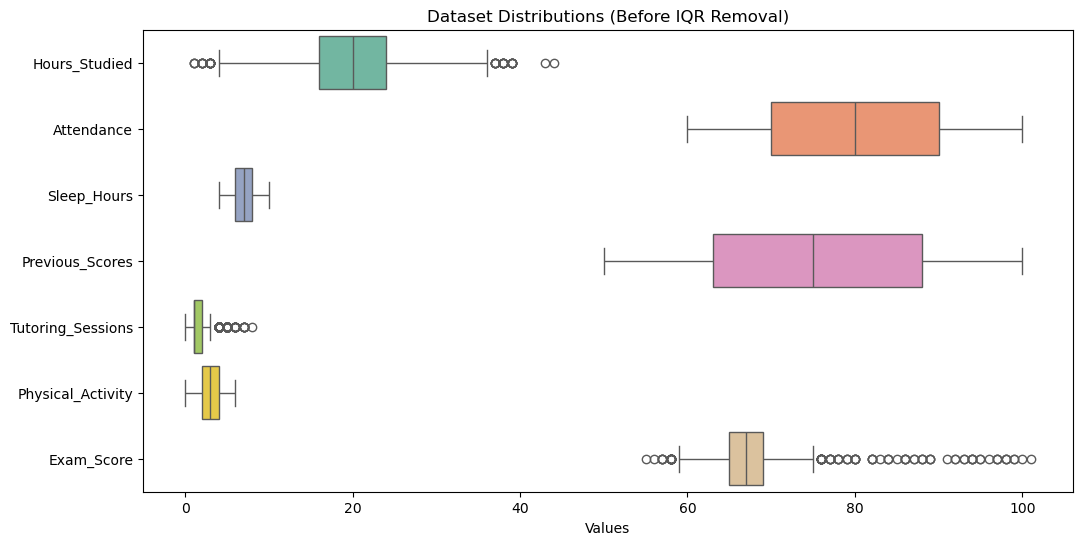

In [161]:
# Visualize the dataset before removing outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols], orient="h", palette="Set2")
plt.title("Dataset Distributions (Before IQR Removal)")
plt.xlabel("Values")
plt.show()

In [162]:
# Apply IQR to filter out rows with extreme values in ANY numerical column
df_cleaned = df.copy()

for col in num_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    # Keep only rows within bounds
    df_cleaned = df_cleaned[
        (df_cleaned[col] >= lower_bound) & 
        (df_cleaned[col] <= upper_bound)
    ]

print("Outliers successfully removed! Dataset saved as 'df_cleaned'.")

Outliers successfully removed! Dataset saved as 'df_cleaned'.


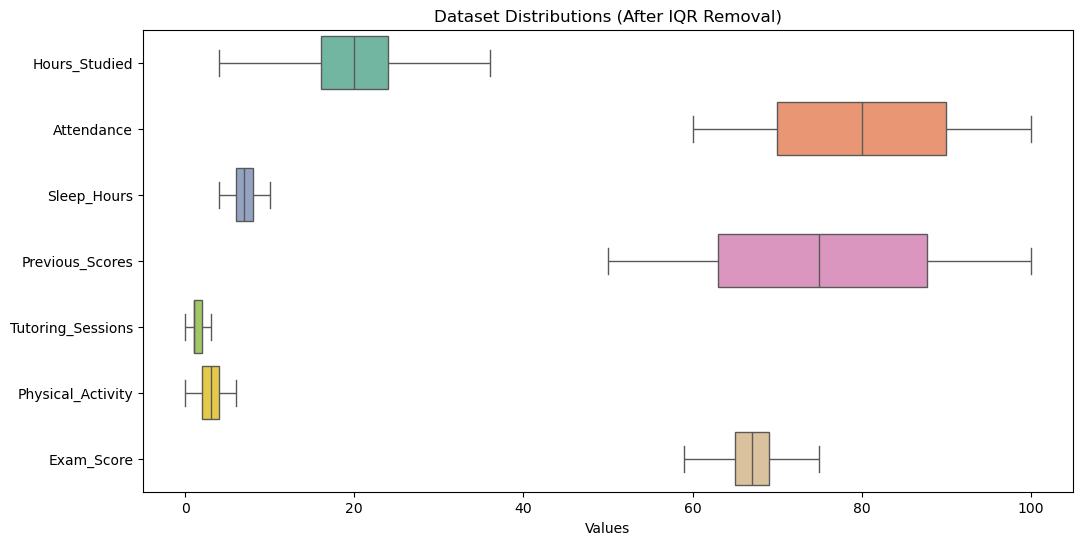

=== Outlier Removal Summary ===
Original dataset rows: 6607
Cleaned dataset rows:  6054
Total rows removed:    553


In [163]:
# Visualize the dataset after cleanup and print the summary for your report
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cleaned[num_cols], orient="h", palette="Set2")
plt.title("Dataset Distributions (After IQR Removal)")
plt.xlabel("Values")
plt.show()

print("=== Outlier Removal Summary ===")
print(f"Original dataset rows: {df.shape[0]}")
print(f"Cleaned dataset rows:  {df_cleaned.shape[0]}")
print(f"Total rows removed:    {df.shape[0] - df_cleaned.shape[0]}")

In [164]:
# Separate target variable and features
TARGET = "Exam_Score"

# Drop target from features
features = df_cleaned.drop(columns=[TARGET])
target = df_cleaned[TARGET]

print("Target variable:", TARGET)
print("Number of features:", features.shape[1])
print("Feature columns:", features.columns.tolist())

Target variable: Exam_Score
Number of features: 19
Feature columns: ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [165]:
# Identify categorical columns
cat_cols = features.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Apply One-Hot Encoding
features_encoded = pd.get_dummies(features, columns=cat_cols, drop_first=True)

# Apply Standard Scaling
scaler = StandardScaler()
features_scaled_array = scaler.fit_transform(features_encoded)

# Convert back to DataFrame
features_final = pd.DataFrame(
    features_scaled_array, 
    columns=features_encoded.columns
)

print("New shape after encoding:", features_final.shape)
features_final.head()

Categorical columns to encode: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']
New shape after encoding: (6054, 27)


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,Access_to_Resources_Medium,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,0.516070,0.350283,-0.023377,-0.147117,-1.314932,0.037064,1.999794,-1.023737,-0.497469,-1.006962,...,0.806530,0.660529,-0.804579,1.227531,-0.338388,0.995715,-0.497469,-0.659498,0.819704,0.856839
1,-0.176485,-1.389206,0.657031,-1.122403,0.718426,1.008430,1.999794,-1.023737,-0.497469,0.993086,...,0.806530,0.660529,-0.804579,-0.814643,-0.338388,-1.004304,-0.497469,1.516306,-1.219953,-1.167080
2,0.689209,1.567925,-0.023377,1.106823,0.718426,1.008430,-0.500052,0.976813,-0.497469,0.993086,...,0.806530,0.660529,1.242886,-0.814643,-0.338388,-1.004304,2.010174,-0.659498,0.819704,0.856839
3,1.554902,0.785155,0.657031,1.594466,-0.298253,1.008430,1.999794,-1.023737,-0.497469,0.993086,...,0.806530,0.660529,-0.804579,-0.814643,-0.338388,0.995715,-0.497469,1.516306,-1.219953,0.856839
4,-0.176485,1.046078,-0.703785,-0.704423,1.735105,1.008430,-0.500052,0.976813,-0.497469,0.993086,...,-1.239879,0.660529,1.242886,-0.814643,-0.338388,-1.004304,-0.497469,-0.659498,0.819704,-1.167080


In [166]:
# For Supervised Learning (Regression)
X_regression = features_final.copy()
Y_regression = target.copy()

# For Unsupervised Learning (Clustering)
X_clustering = features_final.copy() 

In [167]:
#SUPERVISED LEARNING STARTS HERE
X_regression.shape, Y_regression.shape

((6054, 27), (6054,))

In [168]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_regression, Y_regression, test_size=0.2, random_state=1)

In [169]:
X_train.shape, Y_train.shape

((4843, 27), (4843,))

In [170]:
X_test.shape, Y_test.shape

((1211, 27), (1211,))

In [171]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [172]:
linear_model = LinearRegression()
linear_model.fit(X_train, Y_train)
print("Coefficients:", linear_model.coef_)
print("Intercept:", linear_model.intercept_)

Coefficients: [ 1.72221095e+00  2.29780591e+00  2.52963771e-02  7.07488602e-01
  4.92310698e-01  2.43230012e-01 -7.96950378e-01 -5.01971735e-01
 -7.94334128e-01 -4.88995475e-01  2.47924232e-01 -4.57456610e-01
 -2.47569497e-01  2.66928662e-01 -4.80788267e-01 -2.36549584e-01
 -2.98116564e-01 -2.42065672e-01  4.04704414e-04  2.44674678e-01
  4.88119418e-01 -3.02562259e-01 -2.37181747e-01  2.09432148e-01
  2.29784127e-01  4.88625659e-01 -5.30169766e-03]
Intercept: 66.97951487046507


In [173]:
def evaluate_model(model):
    preds = model.predict(X_test) # Predict once to save time
    print("=== Model Evaluation ===")
    print("Mean Absolute Error:", mean_absolute_error(Y_test, preds))
    print("Mean Squared Error:", mean_squared_error(Y_test, preds))
    print("R^2 Score:", r2_score(Y_test, preds))

In [174]:
evaluate_model(linear_model)

=== Model Evaluation ===
Mean Absolute Error: 0.28001812034649404
Mean Squared Error: 0.10887080109601702
R^2 Score: 0.989500092786287


In [175]:
from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=0.001)
ridge_model.fit(X_train, Y_train)
evaluate_model(ridge_model)

=== Model Evaluation ===
Mean Absolute Error: 0.2800181445278376
Mean Squared Error: 0.10887081962450136
R^2 Score: 0.9895000909993307


In [176]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.001)
lasso_model.fit(X_train, Y_train)
evaluate_model(lasso_model)

=== Model Evaluation ===
Mean Absolute Error: 0.2801872245229988
Mean Squared Error: 0.10902718424892062
R^2 Score: 0.9894850106101779


In [177]:
from sklearn.linear_model import ElasticNet
elastic_model = ElasticNet(alpha=0.001)
elastic_model.fit(X_train, Y_train)
evaluate_model(elastic_model)

=== Model Evaluation ===
Mean Absolute Error: 0.28015433357694186
Mean Squared Error: 0.10899528107291312
R^2 Score: 0.9894880874717839


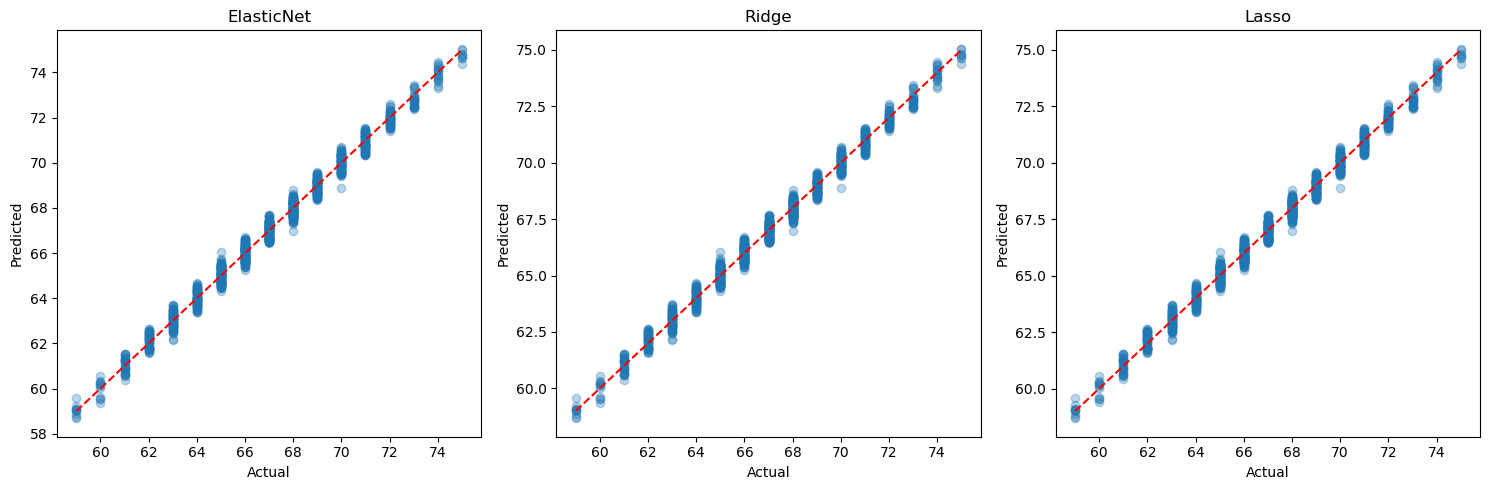

In [178]:
import matplotlib.pyplot as plt

models = {
    'ElasticNet': elastic_model,
    'Ridge': ridge_model,
    'Lasso': lasso_model
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, model) in zip(axes, models.items()):
    Y_pred = model.predict(X_test)
    ax.scatter(Y_test, Y_pred, alpha=0.3)
    ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--')  # perfect prediction line
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(name)

plt.tight_layout()
plt.show()